# EDA-PREPROCESO-MODELACIONES TFM

In [1]:
# libraries
import pandas as pd
import numpy as np
import functools as ft
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
# modelacion
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import lightgbm as lgb
# encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler

# seleccion de modelos
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2, mutual_info_classif,
    RFE, SelectFromModel, VarianceThreshold
)

#otros
import time
import warnings
warnings.filterwarnings('ignore')

## Carga de datos

In [2]:
# carga de datos
dt_librosa = pd.read_csv("/home/estebanm/Escritorio/docs_tfm/proyecto_tfm/data/silver/data_aumentada_castellano.csv")

dt_librosa.head()

,Unnamed: 0,dementia,label,gender,age,total_words,total_sentences,sentence_length_mean,sentence_length_std,type_token_ratio,...,pause_duration_mean,pause_time_ratio,speech_segment_duration_mean,speech_segment_duration_cv,pause_duration_skewness,pause_duration_kurtosis,voiced_ratio,mmse_df_info,schooling_years,articulation_rate_wpm
0,0,2,ad,M,57.0,71.0,4.0,17.750000,14.872374,0.690141,...,0.329075,0.250182,0.867556,0.703391,2.069982,4.332522,0.708787,13.0,17.0,64.482952
1,1,2,ad,M,65.0,70.0,3.0,23.333333,3.399346,0.685714,...,0.344533,0.250000,0.612211,0.645111,1.558600,1.956037,0.562693,28.0,NaN,135.489676
2,2,2,ad,M,67.0,77.0,4.0,19.250000,8.842370,0.714286,...,0.384000,0.250217,0.892690,0.718931,3.689300,15.348264,0.702867,23.0,17.0,167.357083
3,3,2,ad,M,69.0,68.0,1.0,68.000000,0.000000,0.705882,...,0.337778,0.250219,2.122000,1.420813,0.457952,-0.760515,0.931519,28.0,12.0,149.300752
4,4,2,ad,M,72.0,66.0,3.0,22.000000,13.140269,0.742424,...,0.468571,0.250203,0.578000,0.515021,1.403975,1.385860,0.705452,19.0,8.0,67.159085


In [3]:
dt_librosa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2357 entries, 0 to 2356
Data columns (total 51 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    2357 non-null   int64  
 1   dementia                      2357 non-null   int64  
 2   label                         2357 non-null   object 
 3   gender                        2357 non-null   object 
 4   age                           2357 non-null   float64
 5   total_words                   2357 non-null   float64
 6   total_sentences               2357 non-null   float64
 7   sentence_length_mean          2357 non-null   float64
 8   sentence_length_std           2357 non-null   float64
 9   type_token_ratio              2357 non-null   float64
 10  mattr_50                      2357 non-null   float64
 11  noun_ratio                    2357 non-null   float64
 12  content_verb_ratio            2357 non-null   float64
 13  adj

In [4]:
dt_librosa.describe()

,Unnamed: 0,dementia,age,total_words,total_sentences,sentence_length_mean,sentence_length_std,type_token_ratio,mattr_50,noun_ratio,...,pause_duration_mean,pause_time_ratio,speech_segment_duration_mean,speech_segment_duration_cv,pause_duration_skewness,pause_duration_kurtosis,voiced_ratio,mmse_df_info,schooling_years,articulation_rate_wpm
count,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,...,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2355.000000,2342.000000,2357.000000
mean,1178.000000,0.533305,76.860485,69.311105,3.277453,33.464285,5.150867,0.702931,0.744476,0.300569,...,0.336303,0.250088,0.849151,0.700635,1.573770,3.175807,0.719023,25.997863,9.090407,133.154173
std,680.551615,0.747558,7.533849,6.817322,2.390828,21.531436,4.813878,0.033201,0.031346,0.039270,...,0.089970,0.000199,0.366809,0.129569,0.739086,3.886438,0.128968,4.089008,3.294647,38.579887
min,0.000000,0.000000,50.000000,43.000000,0.914264,3.266667,-0.171225,0.450000,0.560000,0.137255,...,0.134261,0.249589,0.325053,0.386939,-0.378134,-1.465031,0.120301,9.000000,-0.004906,31.208930
25%,589.000000,0.000000,71.000445,66.000000,1.788882,16.200000,0.498097,0.694219,0.733171,0.272727,...,0.271444,0.249970,0.613476,0.607869,1.105490,0.677622,0.667853,24.000000,7.363995,106.449872
50%,1178.000000,0.000000,77.654854,67.083747,2.617194,28.349131,5.240948,0.711764,0.751236,0.304348,...,0.337607,0.250065,0.751404,0.687857,1.475772,2.016621,0.741172,27.478113,8.005982,134.271590
75%,1767.000000,1.000000,82.343863,70.000000,4.555989,44.198288,7.348469,0.720304,0.760250,0.330977,...,0.396885,0.250239,0.957296,0.776520,1.945598,4.260383,0.805806,28.971333,11.210603,161.310748
max,2356.000000,2.000000,96.000000,144.000000,30.000000,95.000000,27.500000,0.776119,0.819091,0.385714,...,0.657000,0.250597,4.214857,1.424362,4.894557,26.052424,0.967681,32.000000,19.000000,279.921686


In [5]:
dt_librosa.dementia.value_counts(normalize=True)

dementia
0    0.621553
1    0.223589
2    0.154858
Name: proportion, dtype: float64

In [6]:
dt_librosa['dementia'] = dt_librosa['dementia'].replace(2, 1)

In [7]:
dt_librosa.dementia.value_counts(normalize=True)

dementia
0    0.621553
1    0.378447
Name: proportion, dtype: float64

## Preprocesamiento

### Valores perdidos-imputaciones

In [8]:
dt_librosa.isnull().sum()

Unnamed: 0                       0
dementia                         0
label                            0
gender                           0
age                              0
total_words                      0
total_sentences                  0
sentence_length_mean             0
sentence_length_std              0
type_token_ratio                 0
mattr_50                         0
noun_ratio                       0
content_verb_ratio               0
adj_adv_ratio                    0
function_word_ratio              0
subordinate_sentence_ratio       0
lexical_repetitions              0
reformulations                   0
fillers                          0
idea_density                     0
local_coherence_bigram          90
lexical_error_rate               0
pronoun_to_propn_ratio           0
mean_word_length                 0
readability                      0
incomplete_sentence_ratio        0
speech_rate_wpm                  0
f0_mean                          0
f0_std              

In [9]:
dt_librosa.gender.value_counts()

gender
W    1692
M     665
Name: count, dtype: int64

In [10]:
# porcentaje de valores perdidos
dt_librosa['gender'].isnull().sum()/len(dt_librosa) * 100

0.0

In [11]:
# imputaciones con mediana
def imputation_nas(df, var):
    """ Imputaciones con la mediana """
    df[var] = df[var].fillna(df[var].median())
    return df[var]


In [12]:
imputation_nas(dt_librosa, 'local_coherence_bigram')

0       0.000000
1       0.000000
2       0.000000
3       0.000067
4       0.000000
          ...   
2352   -0.000242
2353   -0.000307
2354    0.000100
2355    0.016532
2356    0.000057
Name: local_coherence_bigram, Length: 2357, dtype: float64

In [13]:
imputation_nas(dt_librosa, 'mmse_df_info')

0       13.000000
1       28.000000
2       23.000000
3       28.000000
4       19.000000
          ...    
2352    29.939767
2353    22.560554
2354    24.425479
2355    27.427152
2356    22.950260
Name: mmse_df_info, Length: 2357, dtype: float64

In [14]:
imputation_nas(dt_librosa, 'schooling_years')

0       17.000000
1        8.005982
2       17.000000
3       12.000000
4        8.000000
          ...    
2352    11.909458
2353     6.011416
2354    16.993945
2355     8.015323
2356    16.237475
Name: schooling_years, Length: 2357, dtype: float64

In [15]:
# Identificar columnas categóricas
cat_cols = dt_librosa.select_dtypes(include=['object', 'category']).columns.tolist()
# calcular la moda para cada columna categorica
modas = {}
for col in cat_cols:
    moda = dt_librosa[col].mode()
    if not moda.empty:
        modas[col] = moda[0]
        print(f"{col}: Moda = '{modas[col]}' ({dt_librosa[col].isna().sum()} nulos a reemplazar)")
    else:
        modas[col] = None
        print(f"{col}: No hay moda, todos los valores son NAN's")

# imputar valores nulos
dt_librosa = dt_librosa.copy()
for col, moda_valor in modas.items():
    if moda_valor is not None:
        # contal nulos antes y despues
        nulos_antes = dt_librosa[col].isna().sum()
        dt_librosa[col] = dt_librosa[col].fillna(moda_valor)
        nulos_despues = dt_librosa[col].isna().sum()

        print(f"{col}: {nulos_antes}→ {nulos_despues} nulos ")

label: Moda = 'hc' (0 nulos a reemplazar)
gender: Moda = 'W' (0 nulos a reemplazar)
label: 0→ 0 nulos 
gender: 0→ 0 nulos 


In [16]:
dt_librosa.isnull().sum()

Unnamed: 0                      0
dementia                        0
label                           0
gender                          0
age                             0
total_words                     0
total_sentences                 0
sentence_length_mean            0
sentence_length_std             0
type_token_ratio                0
mattr_50                        0
noun_ratio                      0
content_verb_ratio              0
adj_adv_ratio                   0
function_word_ratio             0
subordinate_sentence_ratio      0
lexical_repetitions             0
reformulations                  0
fillers                         0
idea_density                    0
local_coherence_bigram          0
lexical_error_rate              0
pronoun_to_propn_ratio          0
mean_word_length                0
readability                     0
incomplete_sentence_ratio       0
speech_rate_wpm                 0
f0_mean                         0
f0_std                          0
f0_range      

In [17]:
dt_librosa.columns

Index(['Unnamed: 0', 'dementia', 'label', 'gender', 'age', 'total_words',
       'total_sentences', 'sentence_length_mean', 'sentence_length_std',
       'type_token_ratio', 'mattr_50', 'noun_ratio', 'content_verb_ratio',
       'adj_adv_ratio', 'function_word_ratio', 'subordinate_sentence_ratio',
       'lexical_repetitions', 'reformulations', 'fillers', 'idea_density',
       'local_coherence_bigram', 'lexical_error_rate',
       'pronoun_to_propn_ratio', 'mean_word_length', 'readability',
       'incomplete_sentence_ratio', 'speech_rate_wpm', 'f0_mean', 'f0_std',
       'f0_range', 'loudness_mean', 'loudness_std', 'jitter_local',
       'shimmer_local', 'hnr', 'alpha_ratio', 'hammarberg_index',
       'spectral_slope_mean', 'spectral_slope_std', 'duracion_s',
       'pause_count', 'pause_duration_mean', 'pause_time_ratio',
       'speech_segment_duration_mean', 'speech_segment_duration_cv',
       'pause_duration_skewness', 'pause_duration_kurtosis', 'voiced_ratio',
       'mmse_df_

In [18]:
# Eliminar variable no relevantes
dt_lib = dt_librosa.drop(['Unnamed: 0', 'label'], axis=1)

In [19]:
# dimensiones datos
dt_lib.shape

(2357, 49)

In [20]:
# eliminar los valores perdidos
dt_lib= dt_lib.dropna()

In [21]:
# revisar variable dependiente
dt_lib.dementia.value_counts(normalize=True)

dementia
0    0.621553
1    0.378447
Name: proportion, dtype: float64

### Transformaciones

In [22]:
# genero
dt_lib.gender.value_counts()

gender
W    1692
M     665
Name: count, dtype: int64

In [23]:
# gender
encoded_df = pd.get_dummies(dt_lib[['gender']], prefix='gender', drop_first=True)
dt_lib = pd.concat([dt_lib, encoded_df], axis=1)

In [24]:
dt_lib = dt_lib.drop(['gender'], axis=1)

In [25]:
# schooling_years
dt_lib['schooling_years'] = pd.cut(
    dt_lib['schooling_years'],
    bins=[0, 6, 8.5, 11, 19],
    labels=['basica', 'media', 'tecnica', 'universitaria'],
    include_lowest=True
)

In [26]:
encoded_df = pd.get_dummies(dt_lib[['schooling_years']], prefix='schooling_years', drop_first=True)
dt_lib = pd.concat([dt_lib, encoded_df], axis=1)

In [27]:
dt_lib = dt_lib.drop(['schooling_years'], axis=1)

In [28]:
# age
dt_lib['age'] = pd.cut(
    dt_lib['age'],
    bins=[50, 71, 77, 82, 96],
    labels=['adulto_q25', 'adulto_mediano', 'adulto_q75', 'adulto_max'],
    include_lowest=True
)

In [29]:
# age
# crear orden
capacidad_order = ['adulto_q25', 'adulto_mediano', 'adulto_q75', 'adulto_max']
# crear encoder
ordinal_encoder = OrdinalEncoder(categories=[capacidad_order])
# tranformar
dt_lib['age'] = ordinal_encoder.fit_transform(dt_lib[['age']])

In [30]:
# eliminar los valores perdidos
dt_lib = dt_lib.dropna()

In [31]:
dt_lib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2357 entries, 0 to 2356
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   dementia                       2357 non-null   int64  
 1   age                            2357 non-null   float64
 2   total_words                    2357 non-null   float64
 3   total_sentences                2357 non-null   float64
 4   sentence_length_mean           2357 non-null   float64
 5   sentence_length_std            2357 non-null   float64
 6   type_token_ratio               2357 non-null   float64
 7   mattr_50                       2357 non-null   float64
 8   noun_ratio                     2357 non-null   float64
 9   content_verb_ratio             2357 non-null   float64
 10  adj_adv_ratio                  2357 non-null   float64
 11  function_word_ratio            2357 non-null   float64
 12  subordinate_sentence_ratio     2357 non-null   f

In [32]:
# eliminar los valores perdidos
dt_lib = dt_lib.dropna()

## Modelos

In [33]:
#  Separar las variables X & y
X = dt_lib.drop('dementia', axis=1)
y = dt_lib['dementia']

print(f"\nX shape:{X.shape}")
print(f"\ny shape:{y.shape}")
print(f"n Distribucion de clases:")
print(y.value_counts(normalize=True))


X shape:(2357, 50)

y shape:(2357,)
n Distribucion de clases:
dementia
0    0.621553
1    0.378447
Name: proportion, dtype: float64


In [34]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=10, stratify=y)
print(f'Train set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nChurn en train: {y_train.mean()*100:.1f}%')
print(f'Churn en test: {y_test.mean()*100:.1f}%')

Train set: (1649, 50)
Test set: (708, 50)

Churn en train: 37.8%
Churn en test: 37.9%


## StandardScaler

In [35]:
# standarization
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
X_train_st = std.fit_transform(X_train)
X_test_st = std.transform(X_test)


## Seleccion de caracteristicas

In [36]:
# SelectKBest con Anova F-test

k_best = 20
selector_kbest = SelectKBest(score_func=f_classif, k=k_best)
X_train_kbest = selector_kbest.fit_transform(X_train_st, y_train)
X_test_kbest = selector_kbest.transform(X_test_st)

print('FILTER METHOD: SelectKBest (ANOVA F-test)')
print('='*60)
print(f'K (features seleccionadas): {k_best}')
print(f'Features originales: {X_train.shape[1]}')
print(f'Features seleccionadas: {X_train_kbest.shape[1]}')

# obtener los scores
feature_scores = pd.DataFrame({
    'feature': X_train.columns,
    'score': selector_kbest.scores_
}).sort_values('score', ascending=False)

print(f"\nTop {k_best} features por score F:")
print(feature_scores.head(k_best))

# Entrenar el modelo
model_kbest = RandomForestClassifier(n_estimators=100, random_state=42)
model_kbest.fit(X_train_kbest, y_train)
y_pred_kbest = model_kbest.predict(X_test_kbest)
accuracy_kbest = accuracy_score(y_test, y_pred_kbest)
print(f"\nAccuracy con selectKBest: {accuracy_kbest:.4f}")

FILTER METHOD: SelectKBest (ANOVA F-test)
K (features seleccionadas): 20
Features originales: 50
Features seleccionadas: 20

Top 20 features por score F:
                  feature       score
44           mmse_df_info  919.624529
22        speech_rate_wpm  232.059636
45  articulation_rate_wpm  230.749187
35             duracion_s  193.860712
0                     age  118.744023
32       hammarberg_index   65.869189
37    pause_duration_mean   63.303365
26          loudness_mean   61.241676
36            pause_count   59.783867
24                 f0_std   59.432900
27           loudness_std   55.163180
12    lexical_repetitions   52.732176
28           jitter_local   48.911784
43           voiced_ratio   42.979445
19       mean_word_length   42.580273
2         total_sentences   37.210348
17     lexical_error_rate   32.967441
31            alpha_ratio   32.510958
7              noun_ratio   29.203433
8      content_verb_ratio   24.468760

Accuracy con selectKBest: 0.9336


In [37]:
# Recursive Feature Elimination (RFE)

n_features_rfe = 20
estimator = LogisticRegression(max_iter=1000, random_state=23)
selector_rfe = RFE(estimator, n_features_to_select=n_features_rfe, step=1)
X_train_rfe = selector_rfe.fit_transform(X_train_st, y_train)
X_test_rfe = selector_rfe.transform(X_test_st)

print(f"Wrapper Method: Recursive Feature Elimination")
print(f"="*80)
print(f"Features seleccionadas: {n_features_rfe}")

# selecciondo features con su rankings
feature_ranking = pd.DataFrame({
    'feature': X_train.columns,
    'selected': selector_rfe.support_,
    'ranking': selector_rfe.ranking_
}).sort_values('ranking')

print("\nFeatures seleccionadas (ranking=1):")
print(list(feature_ranking[feature_ranking['ranking'] ==1]['feature']))

# entrenar al modelo
model_rfe = RandomForestClassifier(n_estimators=100, random_state=23)
model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = model_rfe.predict(X_test_rfe)
accuracy_rfe = accuracy_score(y_test, y_pred_rfe)
print(f"\nAccuracy con RFE:{accuracy_rfe:.4f}")

Wrapper Method: Recursive Feature Elimination
Features seleccionadas: 20

Features seleccionadas (ranking=1):
['age', 'schooling_years_media', 'gender_W', 'mmse_df_info', 'voiced_ratio', 'speech_segment_duration_cv', 'spectral_slope_mean', 'hammarberg_index', 'alpha_ratio', 'hnr', 'loudness_mean', 'incomplete_sentence_ratio', 'fillers', 'schooling_years_universitaria', 'lexical_repetitions', 'total_words', 'total_sentences', 'sentence_length_mean', 'reformulations', 'subordinate_sentence_ratio']

Accuracy con RFE:0.9223


\Embedded method: Feature importance

Top 20 features mas impornates:
                       feature  importance
44                mmse_df_info    0.186138
45       articulation_rate_wpm    0.046420
35                  duracion_s    0.034310
28                jitter_local    0.028746
32            hammarberg_index    0.026373
33         spectral_slope_mean    0.026365
22             speech_rate_wpm    0.025618
9                adj_adv_ratio    0.023281
3         sentence_length_mean    0.022986
31                 alpha_ratio    0.022228
43                voiced_ratio    0.021472
11  subordinate_sentence_ratio    0.020796
20                 readability    0.020670
2              total_sentences    0.020647
40  speech_segment_duration_cv    0.019101
34          spectral_slope_std    0.019070
37         pause_duration_mean    0.019057
27                loudness_std    0.018797
36                 pause_count    0.018422
29               shimmer_local    0.018109


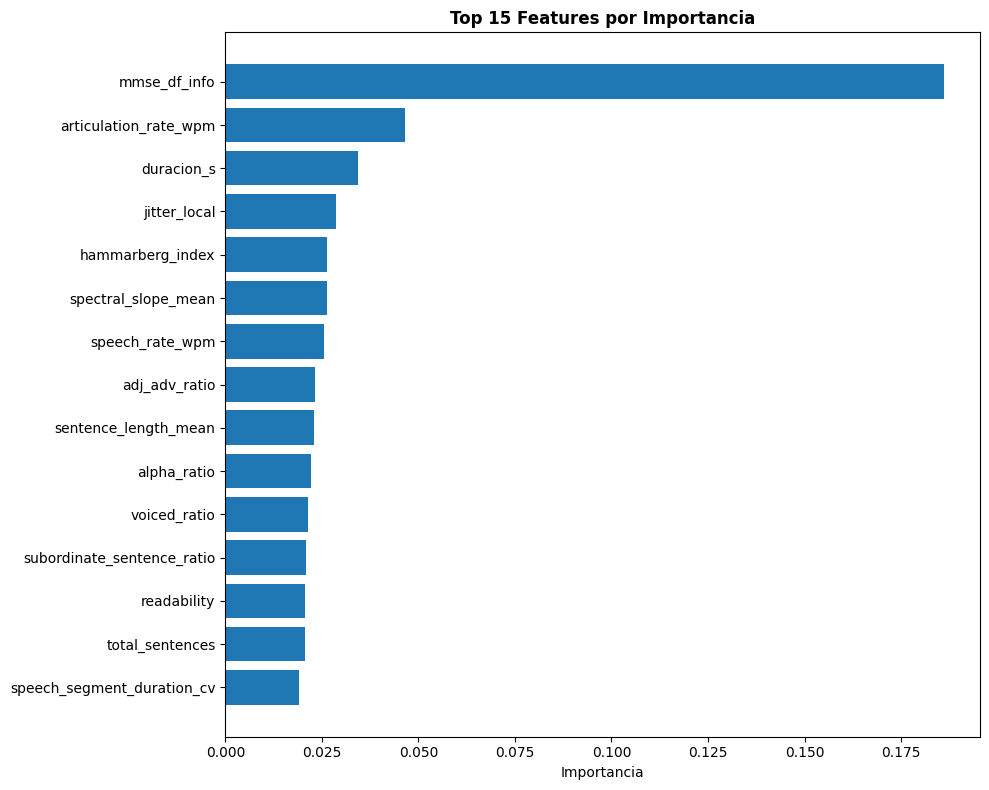

In [38]:
## Feature importance

rf_importance = RandomForestClassifier(n_estimators=100, random_state=23)
rf_importance.fit(X_train_st, y_train)

#obtener importancia
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\Embedded method: Feature importance")
print("="*80)
print(f"\nTop 20 features mas impornates:")
print(importances.head(20))

# visualizaciones
plt.figure(figsize=(10,8))
top_n = 15
plt.barh(range(top_n), importances['importance'].head(top_n))
plt.yticks(range(top_n), importances['feature'].head(top_n))
plt.xlabel('Importancia')
plt.title(f"Top {top_n} Features por Importancia", fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Seleccion de caracteristicas para los modelos

In [39]:
# Se utiliza un mix de variables de los tres metodos revisados
dt_lib = dt_lib[['age', 'schooling_years_media', 'gender_W', 'mmse_df_info', 'voiced_ratio', 
                 'speech_segment_duration_cv', 'spectral_slope_mean', 'hammarberg_index', 'alpha_ratio', 
                 'hnr', 'loudness_mean', 'incomplete_sentence_ratio', 'fillers', 'schooling_years_universitaria', 
                 'lexical_repetitions', 'total_words', 'total_sentences', 'sentence_length_mean', 
                 'reformulations', 'subordinate_sentence_ratio','dementia']]


In [40]:
#  Separar las variables X & y
X = dt_lib.drop('dementia', axis=1)
y = dt_lib['dementia']

print(f"\nX shape:{X.shape}")
print(f"\ny shape:{y.shape}")
print(f"n Distribucion de clases:")
print(y.value_counts(normalize=True))


X shape:(2357, 20)

y shape:(2357,)
n Distribucion de clases:
dementia
0    0.621553
1    0.378447
Name: proportion, dtype: float64


In [41]:
X

,age,schooling_years_media,gender_W,mmse_df_info,voiced_ratio,speech_segment_duration_cv,spectral_slope_mean,hammarberg_index,alpha_ratio,hnr,loudness_mean,incomplete_sentence_ratio,fillers,schooling_years_universitaria,lexical_repetitions,total_words,total_sentences,sentence_length_mean,reformulations,subordinate_sentence_ratio
0,0.0,False,False,13.000000,0.708787,0.703391,0.004271,29.970024,-10.169508,4.803319,0.502629,0.000000,2.000000,True,1.000000,71.000000,4.000000,17.750000,1.000000,0.250000
1,0.0,True,False,28.000000,0.562693,0.645111,-0.005464,25.279516,-17.297457,4.168043,0.779163,0.333333,2.000000,False,1.000000,70.000000,3.000000,23.333333,2.000000,0.333333
2,0.0,False,False,23.000000,0.702867,0.718931,-0.021959,26.212109,-11.231874,3.488664,0.701063,0.000000,4.000000,True,0.000000,77.000000,4.000000,19.250000,3.000000,0.250000
3,0.0,False,False,28.000000,0.931519,1.420813,-0.014187,32.717693,-16.526716,9.336919,0.554351,0.000000,2.000000,True,1.000000,68.000000,1.000000,68.000000,2.000000,1.000000
4,1.0,True,False,19.000000,0.705452,0.515021,-0.005194,28.463724,-14.597221,6.281316,0.424299,0.333333,2.000000,False,0.000000,66.000000,3.000000,22.000000,2.000000,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2352,0.0,False,False,29.939767,0.562068,0.480436,0.025768,23.052549,-9.571679,3.130028,0.797508,-0.006321,1.979291,True,-0.000462,67.040162,1.625352,46.042786,1.992654,0.679683
2353,1.0,True,True,22.560554,0.727467,0.659559,0.055787,23.843020,-9.255175,6.660617,0.799629,-0.003459,2.011876,False,-0.013650,58.435114,1.014003,58.494512,1.211012,0.999616
2354,1.0,False,True,24.425479,0.780517,0.694408,0.050392,27.547362,-12.127923,5.366241,1.016429,0.003311,1.980970,True,0.018156,66.686610,0.941219,66.850307,2.004380,0.995992
2355,3.0,True,True,27.427152,0.336222,0.482275,0.022202,30.112908,-16.553078,3.285776,0.546626,0.192891,1.996701,False,0.582965,70.855448,3.914619,37.056658,1.967033,0.608760


In [42]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=10, stratify=y)
print(f'Train set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nChurn en train: {y_train.mean()*100:.1f}%')
print(f'Churn en test: {y_test.mean()*100:.1f}%')

Train set: (1649, 20)
Test set: (708, 20)

Churn en train: 37.8%
Churn en test: 37.9%


In [43]:
y_train

1404    0
1206    0
1537    1
798     0
2338    0
       ..
197     0
1147    0
10      1
1628    0
1042    1
Name: dementia, Length: 1649, dtype: int64

In [44]:
# standarization
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
X_train_st = std.fit_transform(X_train)
X_test_st = std.transform(X_test)


In [45]:
X_train_st

array([[-1.37571167,  0.99576397, -1.59569313, ..., -0.08415497,
        -0.17587037, -0.05976958],
       [ 0.39038295,  0.99576397,  0.62668691, ...,  0.00796126,
        -0.18613025, -0.02463606],
       [-1.37571167,  0.99576397,  0.62668691, ..., -1.04920374,
        -0.15965198, -1.03577053],
       ...,
       [ 0.39038295, -1.00425405, -1.59569313, ..., -1.18334062,
        -0.17530629, -1.14839797],
       [-1.37571167, -1.00425405, -1.59569313, ...,  0.02070172,
        -0.18336524,  0.61743318],
       [ 1.27343026, -1.00425405,  0.62668691, ...,  1.65219765,
        -0.17697279,  1.55419228]])

# Modelos

## Neural Networks

In [46]:
from sklearn.metrics import log_loss # entropía cruzada

max_iter = 200

# Hago explícitamente la partición interna que hace sklearn en training y test:
X_train2, X_val, y_train, y_val = train_test_split(X_train_st, y_train, stratify=y_train,
                                      test_size=0.3, random_state=1)



In [47]:
from keras.models import Sequential
from IPython.display import clear_output
from time import sleep
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense,  Dropout, Activation
from keras.regularizers import L1, L2
from keras.optimizers import Adam, RMSprop
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import GaussianNoise

model = Sequential()

model.add(Dense(64, input_shape=(X_train2.shape[1],), kernel_regularizer=L2(0.001))) #
#model.add(GaussianNoise(0.01, input_shape=(X_train2.shape[1],)))

#model.add(Dense(64, kernel_regularizer=L2(0.01)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(32, kernel_regularizer=L2(0.01)))
#model.add(LeakyReLU(alpha=0.1))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # la neurona de salida estima la probabilidad de que sea 1

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy', 'AUC'])

2026-03-17 16:15:34.620701: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 16:15:34.922551: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-17 16:15:35.774585: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773782136.288967  219142 gpu_device.cc:2020] Created device /job:localhost/rep

In [48]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,161 (16.25 KB)

 Non-trainable params: 192 (768.00 B)

In [49]:
ruta = "nnet.keras"
losses_val = []
losses_tr  = []

max_iter = 400

callbacks = [ModelCheckpoint(filepath=ruta, monitor="val_loss", verbose=1,
                             save_best_only=True)]



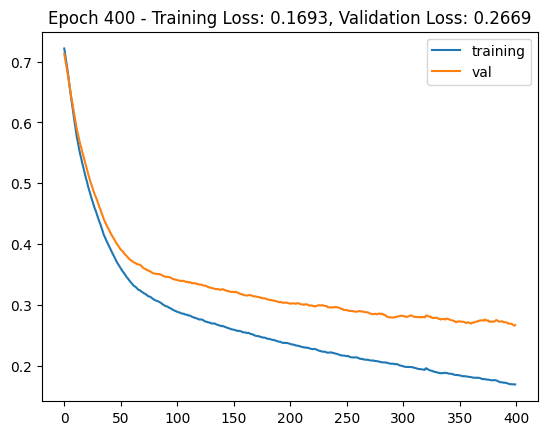

Training complete. Best model saved to nnet.keras


In [50]:
for epoca in range(max_iter):
    history = model.fit(X_train2, y_train, epochs=1,
              validation_data=(X_val, y_val), callbacks=callbacks, verbose=0) # entreno solo 1 época en training

    # The log_loss expects probabilities, and model.predict() outputs probabilities with sigmoid activation
    loss_val = log_loss(y_val, model.predict(X_val, verbose=0))
    loss_tr  = log_loss(y_train, model.predict(X_train2, verbose=0))

    losses_val.append(loss_val)
    losses_tr.append(loss_tr)
    clear_output(wait=True)
    plt.plot(losses_tr, label="training")
    plt.plot(losses_val, label="val")
    plt.legend()
    plt.title(f"Epoch {epoca+1} - Training Loss: {loss_tr:.4f}, Validation Loss: {loss_val:.4f}")
    plt.show()
    sleep(0.1)

print("Training complete. Best model saved to", ruta)

In [51]:
from keras.models import load_model

model = load_model(ruta)


In [52]:
umbral = 0.5
clase_predicha = (1*model.predict(X_test_st)>umbral).flatten()
(clase_predicha == y_test.values).mean()

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


0.882768361581921

In [53]:
umbral = 0.5
clase_predicha = (1*model.predict(X_train2)>umbral).flatten()
(clase_predicha == y_train.values).mean()

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


0.9402079722703639

In [54]:
# evaluate the model
y_pred_train = (model.predict(X_train2) > 0.5).astype(int)
y_pred_test = (model.predict(X_test_st) > 0.5).astype(int)

cm_train = confusion_matrix(y_train, y_pred_train)
report_train = classification_report(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred_test)
report_test = classification_report(y_test, y_pred_test)

print("Evaluation model en train")
print("Confusion Matrix (Train):\n", cm_train)
print("\nClassification Report (Train):\n", report_train)
print("=" * 100)
print("Evaluation model en test")
print("\nConfusion Matrix (Test):\n", cm_test)
print("\nClassification Report (Test):\n", report_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Evaluation model en train
Confusion Matrix (Train):
 [[679  38]
 [ 31 406]]

Classification Report (Train):
               precision    recall  f1-score   support

           0       0.96      0.95      0.95       717
           1       0.91      0.93      0.92       437

    accuracy                           0.94      1154
   macro avg       0.94      0.94      0.94      1154
weighted avg       0.94      0.94      0.94      1154

Evaluation model en test

Confusion Matrix (Test):
 [[391  49]
 [ 34 234]]

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.92      0.89      0.90       440
           1       0.83      0.87      0.85       268

    accuracy                           0.88       708
   macro avg       0.87      0.88      0.88       708
weighted avg       0.88      0.88      0.88       708

